# Probability Basics with Simulation

This notebook uses Python simulations to build intuition for basic probability concepts.

Topics covered:
- Bernoulli and Binomial random variables
- empirical mean, PDF and PMF
- convergence with increasing sample size
- Gaussian sampling
- conditional probability and Bayes' rule

For each example, I compare empirical results from simulation with theoretical expectations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["font.size"] = 18

rng = np.random.default_rng()

## 1. Bernoulli trials

A Bernoulli random variable takes values 1 (success) with probability $p$
and 0 (failure) with probability $1-p$.

Here I simulate repeated Bernoulli trials and compare the empirical mean and variance
with the theoretical values:

- $\mathbb{E}[X] = p$
- $\mathrm{Var}(X) = p(1-p)$

Empirical mean: 0.3031
Theoretical mean: 0.3000
Empirical variance: 0.2112
Theoretical variance: 0.2100


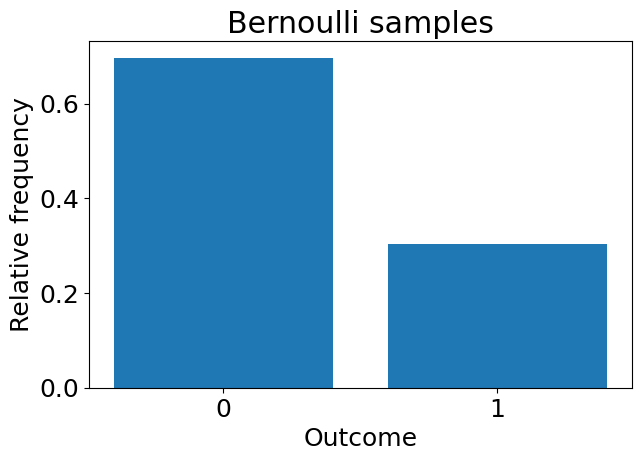

In [2]:
p = 0.3
n = 10000

x = rng.binomial(1, p, size=n)

emp_mean = x.mean()
emp_var = x.var()

theory_mean = p
theory_var = p * (1 - p)

print(f"Empirical mean: {emp_mean:.4f}")
print(f"Theoretical mean: {theory_mean:.4f}")
print(f"Empirical variance: {emp_var:.4f}")
print(f"Theoretical variance: {theory_var:.4f}")

values, counts = np.unique(x, return_counts=True)
plt.bar(values, counts / n)
plt.xticks([0, 1])
plt.xlabel("Outcome")
plt.ylabel("Relative frequency")
plt.title("Bernoulli samples")
plt.show()

## 2. Binomial distribution

If I repeat a Bernoulli trial $m$ times, the number of successes follows
a Binomial distribution.

Here I simulate many repeated experiments and compare the empirical histogram
to the theoretical Binomial PMF:

- $\mathbb{E}[X] = mp$
- $\text{PMF}(X=k) = \begin{pmatrix}m \\ k\end{pmatrix} p^{k}(1-p)^{m-k}$

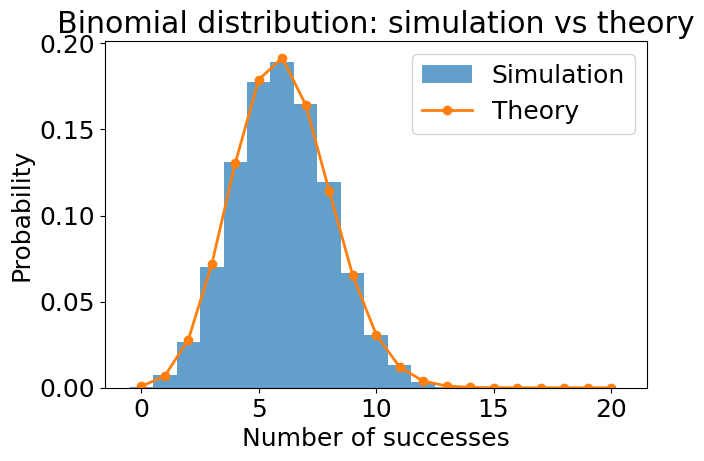

In [3]:
p = 0.3
m = 20
n_exp = 20000

samples = rng.binomial(m, p, size=n_exp)

def binomial_pmf(k, m, p):
    return comb(m, k) * (p ** k) * ((1 - p) ** (m - k))


k_vals = np.arange(m + 1)
pmf_vals = np.array([binomial_pmf(k, m, p) for k in k_vals])

plt.hist(samples, bins=np.arange(-0.5, m + 1.5, 1), density=True, alpha=0.7, label="Simulation")
plt.plot(k_vals, pmf_vals, "o-", lw=2, label="Theory")
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.title("Binomial distribution: simulation vs theory")
plt.legend()
plt.show()

## 3. Convergence of the sample mean

A key idea in probability is that the sample mean approaches the true expectation
as the number of samples increases.

Here I track the running mean of Bernoulli and Binomial samples and compare it to the true mean.

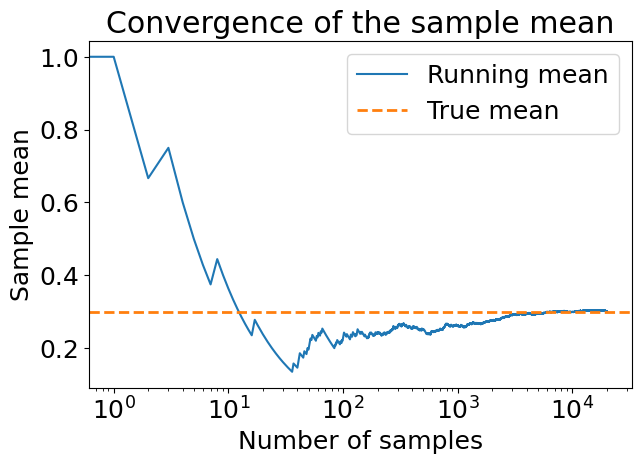

In [4]:
p = 0.3
n = 20000
x = rng.binomial(1, p, size=n)

running_mean = np.cumsum(x) / np.arange(1, n + 1)

plt.semilogx(running_mean, label="Running mean")
plt.axhline(p, c='C1',lw=2, linestyle="--", label="True mean")
plt.xlabel("Number of samples")
plt.ylabel("Sample mean")
plt.title("Convergence of the sample mean")
plt.legend()
plt.show()

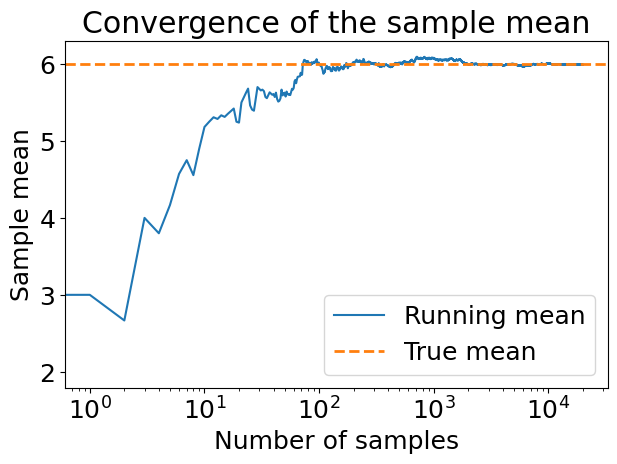

In [5]:
p = 0.3
m = 20
n_exp = 20000
x = rng.binomial(m, p, size=n)

running_mean = np.cumsum(x) / np.arange(1, n + 1)

plt.semilogx(running_mean, label="Running mean")
plt.axhline(m*p, c='C1',lw=2, linestyle="--", label="True mean")
plt.xlabel("Number of samples")
plt.ylabel("Sample mean")
plt.title("Convergence of the sample mean")
plt.legend()
plt.show()

## 4. Gaussian random variables

I now draw samples from a Gaussian distribution and compare the empirical
histogram with the theoretical probability density.

Empirical mean: 1.9858
Theoretical mean: 2.0000
Empirical std: 1.5115
Theoretical std: 1.5000


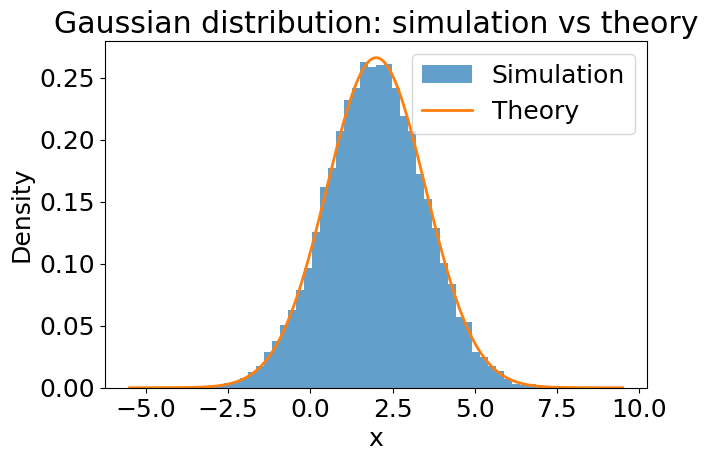

In [6]:
mu = 2.0
sigma = 1.5
n = 20000

samples = rng.normal(mu, sigma, size=n)

def gaussian_pdf(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


print(f"Empirical mean: {samples.mean():.4f}")
print(f"Theoretical mean: {mu:.4f}")
print(f"Empirical std: {samples.std():.4f}")
print(f"Theoretical std: {sigma:.4f}")


xgrid = np.linspace(mu - 5*sigma, mu + 5*sigma, 400)
pdf = gaussian_pdf(xgrid, mu, sigma)

plt.hist(samples, bins=50, density=True, alpha=0.7, label="Simulation")
plt.plot(xgrid, pdf, lw=2, label="Theory")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian distribution: simulation vs theory")
plt.legend()
plt.show()

## 5. Conditional probability and Bayes' rule

Quote from Wikipedia page:

> In medicine and statistics, sensitivity and specificity mathematically describe the accuracy of a test that reports the presence or absence of a medical condition. If individuals who have the condition are considered "positive" and those who do not are considered "negative", then sensitivity is a measure of how well a test can identify true positives and specificity is a measure of how well a test can identify true negatives:
>
> - **Sensitivity (true positive rate)** is the probability of a positive test result, conditioned on the individual truly being positive.
>
> - **Specificity (true negative rate)** is the probability of a negative test result, conditioned on the individual truly being negative.


Suppose:
- 1% of a population has a condition
- a test has 95% sensitivity, 90% specificity

If a person tests positive, what is the probability they actually have the condition?

I estimate this analytically as 
- $P(yes|p) = \frac{P(p|yes)*P(yes)}{P(p|yes)*P(yes)+(1-P(n|no))*P(no)} = \frac{0.95*0.01}{0.95*0.01+0.1*0.99} = 0.0876$

and by simulation.

In [7]:
prevalence = 0.01
sensitivity = 0.95
specificity = 0.90

n = 500000

people_has_condition = rng.random(n) < prevalence

people_test_positive = np.where(
    people_has_condition,
    rng.random(n) < sensitivity,
    rng.random(n) < (1 - specificity)
)

posterior_empirical = people_has_condition[people_test_positive].mean()

posterior_theory = (
    sensitivity * prevalence
    / (sensitivity * prevalence + (1 - specificity) * (1 - prevalence))
)

print(f"Empirical P(condition | positive): {posterior_empirical:.4f}")
print(f"Theoretical P(condition | positive): {posterior_theory:.4f}")

Empirical P(condition | positive): 0.0895
Theoretical P(condition | positive): 0.0876


## Conclusion

In this notebook, I used simulation to study several basic probability concepts:
- Bernoulli and Binomial random variables
- empirical mean, PDF and PMF
- convergence of the sample mean
- Gaussian sampling
- conditional probability via Bayes' rule

